# Exercise 1

## Helper code:

In [1]:
%matplotlib widget

import types
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from numpy import sqrt
import csv
import typing
from collections import namedtuple
from scipy.linalg import solve, inv, pinv
from IPython.display import display, Markdown, Latex

plt.style.use('default')
plt.interactive(True)
plt.rcParams['figure.figsize'] = [10, 5]

DATA_FILE_NAME = "./data_main.csv"

def MatrixToLatex(mat:np.array, command="bmatrix")->str:
    ret = ""
    if len(mat.shape) == 1:
        for i in range(0, mat.shape[0]):
            ret += str(mat[i])
            if i != mat.shape[0] - 1:
                ret += "&"
    else:
        for i in range(0, mat.shape[0]):
            for ii in range(0, mat.shape[1]):
                ret += str(mat[i, ii])
                if ii != mat.shape[1] - 1:
                    ret += "&"
            if i != mat.shape[1] - 1:
                ret += "\\\\"
    return "\\begin{" + command + "} " + ret + "\\end{" + command + "}"

# Data

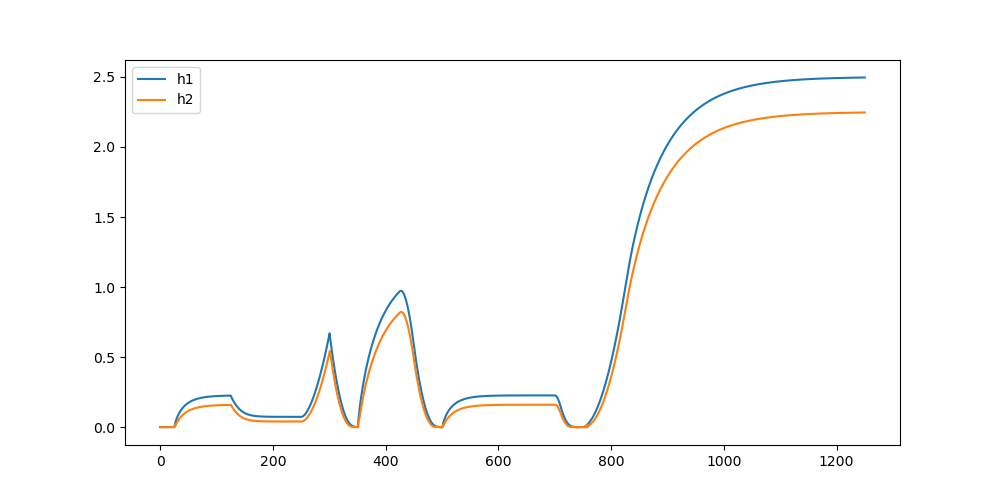

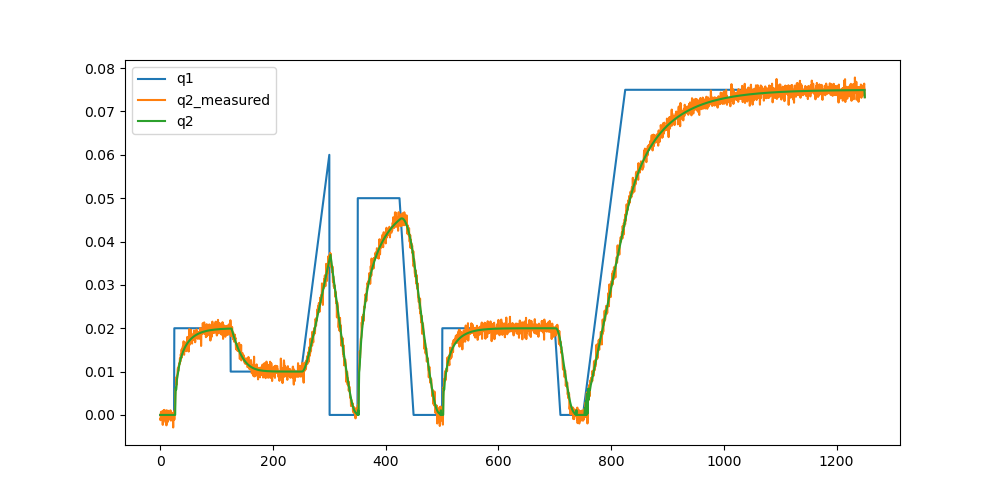

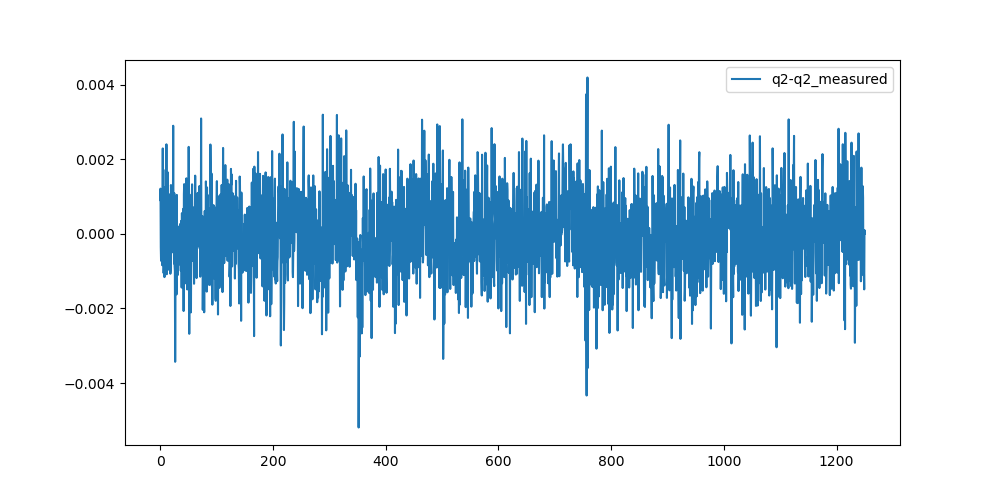

/tmp/ipykernel_538737/1504708029.py:160: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(data.t, [data.k * sqrt(x) for x in data.h2], label="$k\\sqrt{h_2}$")


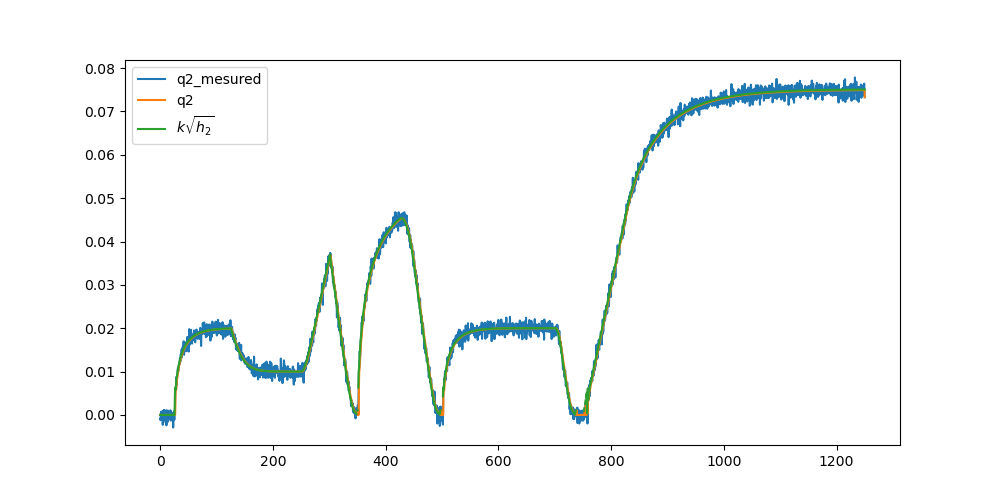

In [2]:
# Loading data and analyzing it

class Sample:
    index:int = 0

    # from data
    t:float = 0
    q1:float = 0,
    h1:float = 0
    h2:float = 0
    q2_measured:float = 0

    # derived
    q2:float = 0
    v1:float = 0 # volume in tank 1
    v2:float = 0 # volume in tank 2
    vt:float = 0 # total volume
    vdif:float = 0
    delta:float = 0 # time delta
    total_inflow:float = 0
    total_outflow:float = 0

    prev:typing.Self = None
    next:typing.Self = None

def SamplesFromFile(filename:str)->list[Sample]:
    samples = []
    with open(DATA_FILE_NAME) as file:
        reader = csv.reader(file, delimiter=";")
        i = 0
        total_inflow = 0.0
        for row in reader:
            break
        for row in reader:
            s = Sample()
            s.index = i
            s.t = np.float64(row[0].replace(",", "."))
            s.q1 = np.float64(row[1].replace(",", "."))
            s.h1 = np.float64(row[2].replace(",", "."))
            s.h2 = np.float64(row[3].replace(",", "."))
            s.q2_measured = np.float64(row[4].replace(",", "."))
            # s.t = np.float64(row["t[sec]"].replace(",", "."))
            # s.q1 = float(row["q1[m3/h]"].replace(",", "."))
            # print(row["q1[m3/h]"])
            # s.h1 = np.float64(row["h1[m]"].replace(",", "."))
            # s.h2 = np.float64(row["h2[m]"].replace(",", "."))
            # s.q2_measured = np.float64(row["q2_measurement[m3/h]"].replace(",", "."))
            if i != 0:
                samples[i-1].next = s
                s.prev = samples[i-1]
                s.delta =  s.t-s.prev.t
                s.total_inflow = total_inflow
            samples.append(s)
            total_inflow += s.q1
            i+=1
    return samples

class Dataset:
    name:str = ""

    n:int = 0

    samples:list[Sample] = []

    # for convenience
    t:npt.ArrayLike = []
    h1:npt.ArrayLike = []
    h2:npt.ArrayLike = []
    v1:npt.ArrayLike = []
    v2:npt.ArrayLike = []
    q1:npt.ArrayLike = []
    q2:npt.ArrayLike = []
    q2_measured:npt.ArrayLike = []
    

    total_time:float = 0
    S1:float = 0
    S2:float = 0
    a:float = 0
    k:float = 0
    inflow_start_index:int = 0

    total_inflow:float = 0
    total_outflow:float = 0

    k_points:list[float] = []
    a_points:list[float] = []

    def __init__(self, filename:str):
        samples = SamplesFromFile(filename)
        i = 0
        while samples[i].q1 == 0:
            i += 1
        s = samples[i]
        self.inflow_start_index = i
        self.S1 = s.q1 / s.next.h1

        ft2 = (samples[i].q1+samples[i+1].q1)
        self.S2 = (ft2 - self.S1*samples[i+2].h1) / samples[i+2].h2

        for s in samples:
            s.v1 = self.S1 * s.h1
            s.v2 = self.S2 * s.h2
            s.vt = s.v1 + s.v2
            if s.prev is not None:
                vexp = s.prev.vt + s.prev.q1
                s.vdif = s.vt-s.prev.vt
                s.q2 = (vexp-s.vt)
                self.total_outflow += s.q2
                s.total_outflow = self.total_outflow
                if s.prev.h2 > 0:
                    self.k_points.append(s.q2/sqrt(s.prev.h2))

        samples[-1].q2 = samples[-1].q2_measured
        samples[-1].vt = samples[-2].vt
        samples[-1].v1 = samples[-2].v1
        samples[-1].v2 = samples[-2].v2

        self.a = samples[self.inflow_start_index+2].v2 / samples[self.inflow_start_index+1].h1
        #self.k = samples[self.inflow_start_index+3].q2 / sqrt(samples[self.inflow_start_index+2].h2)
        self.k = np.mean(self.k_points)

        # Stupidly unoptimized, but shouldn't matter
        self.t = np.array([s.t for s in samples])
        self.h1 = np.array([s.h1 for s in samples])
        self.h2 = np.array([s.h2 for s in samples])
        self.v1 = np.array([s.v1 for s in samples])
        self.v2 = np.array([s.v2 for s in samples])
        self.q1 = np.array([s.q1 for s in samples])
        self.q2_measured = np.array([s.q2_measured for s in samples])
        self.q2 = np.array([s.q2 for s in samples])
        self.n = len(samples)
        self.samples = samples
        self.total_time = samples[-1].t
        self.total_inflow = samples[-1].total_inflow

data = Dataset(DATA_FILE_NAME)

fig = plt.figure()
plt.plot(data.t, data.h1, label="h1")
plt.plot(data.t, data.h2, label="h2")
plt.legend()
plt.show()
fig = plt.figure()
plt.plot(data.t, data.q1, label="q1")
plt.plot(data.t, data.q2_measured, label="q2_measured")
plt.plot(data.t, data.q2, label="q2")
plt.interactive(True)
plt.legend()
plt.show()

fig = plt.figure()
plt.plot(data.t, data.q2-data.q2_measured, label="q2-q2_measured")
plt.legend()
plt.show()

fig = plt.figure()
plt.plot(data.t, data.q2_measured, label="q2_mesured")
plt.plot(data.t, data.q2, label="q2")
plt.plot(data.t, [data.k * sqrt(x) for x in data.h2], label="$k\\sqrt{h_2}$")
plt.legend()
plt.show()

# Solution

The problem is best solved with a filter of order 3, with one control signal, one sensor, and two predicted variables.
It's worth noting that $q_2$ can be precisely predicted from $h_2$, thus given it's high level of white noise it's best to weight the filter towards the predicted value by assuming a high process noise coefficient.

## Equations

$$
\begin{gather}
\text{Predict Step:}\\
\mathbf{\bar x} = \mathbf{F x} + \mathbf{B u} \\
\mathbf{\bar P} = \mathbf{FP{F}}^\mathsf T + \mathbf Q \\
\\
\text{Update Step:}\\
\textbf{S} = \mathbf{H\bar PH}^\mathsf T + \mathbf R \\
\mathbf K = \mathbf{\bar PH}^\mathsf T \mathbf{S}^{-1} \\
\textbf{y} = \mathbf z - \mathbf{H \bar x} \\
\mathbf x =\mathbf{\bar x} +\mathbf{K\textbf{y}} \\
\mathbf P = (\mathbf{I}-\mathbf{KH})\mathbf{\bar P}
\\\\
\text{State Transition Matrix:}\\
F =
\begin{bmatrix}
1 - \alpha S_1^{-1} & \alpha S_1^{-1} & 0 \\
\alpha S_2^{-1} & 1 - \alpha S_2^{-1} & -S_2^{-1} \\
0 & \sqrt{kx_{10}}^{-1} & 0
\end{bmatrix}
\\\\
\text{Control Matrix:}\\
B_u =
\begin{bmatrix}
\mathbf{z}S_1^{-1} \\
0 \\
0
\end{bmatrix}
\end{gather}
$$


## Initial values

$V = \begin{bmatrix} 0&0&0\\\end{bmatrix}^T$

$q_2$ has relatively high noise level, but can be predicted with high degree of certainty from $h_2$, thus a high process noise value is appropriate here.

$R = \begin{bmatrix} 10\end{bmatrix}$

Initial variance seems to have little effect

$P = \begin{bmatrix} 1&0&0\\0&1&0\\0&0&1\end{bmatrix}$

$H = \begin{bmatrix} 0&0&1\\\end{bmatrix}$

Assuming gaussian white noise of variance 0.01

$Q = \begin{bmatrix} 0.00015625&0.000625&0.000625\\0.000625&0.0025&0.005\\0.00125&0.005&0.01\end{bmatrix}$

## Results

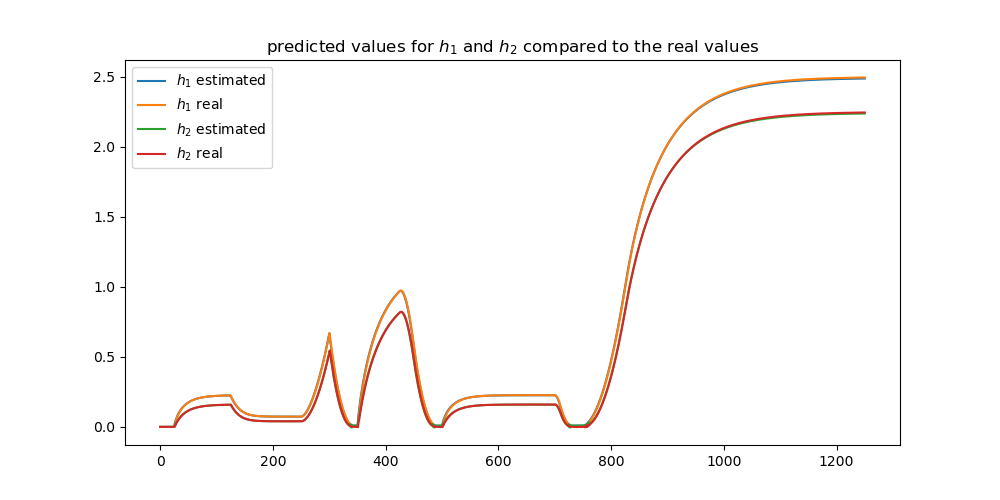

Note: the curves might be too close to distinguish them without using the zoom tool

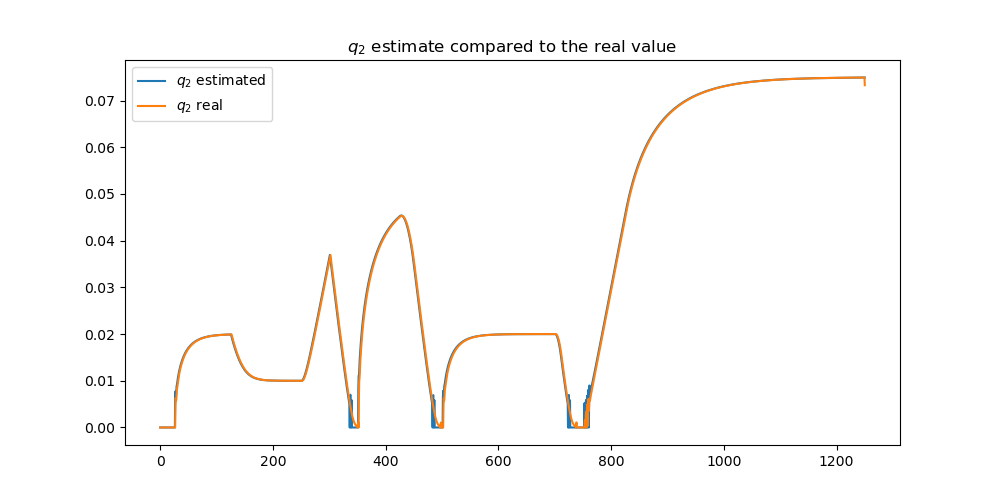

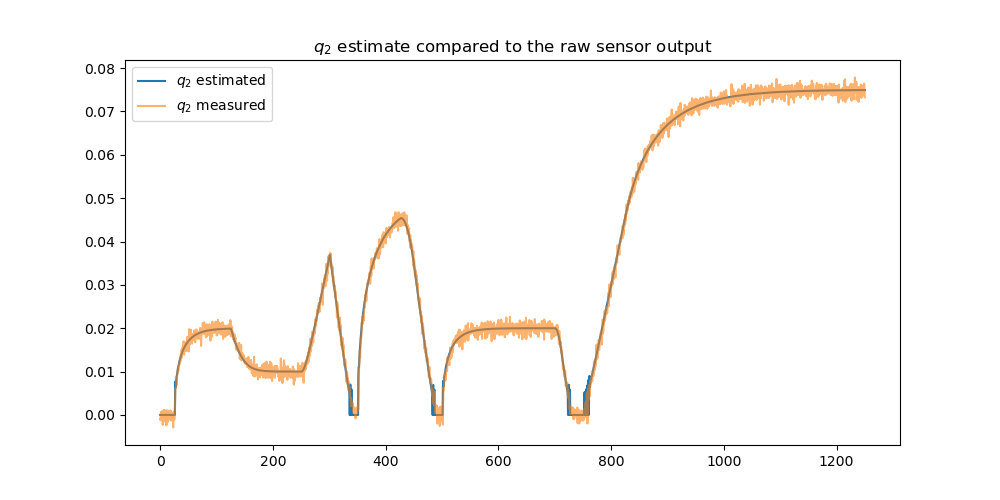

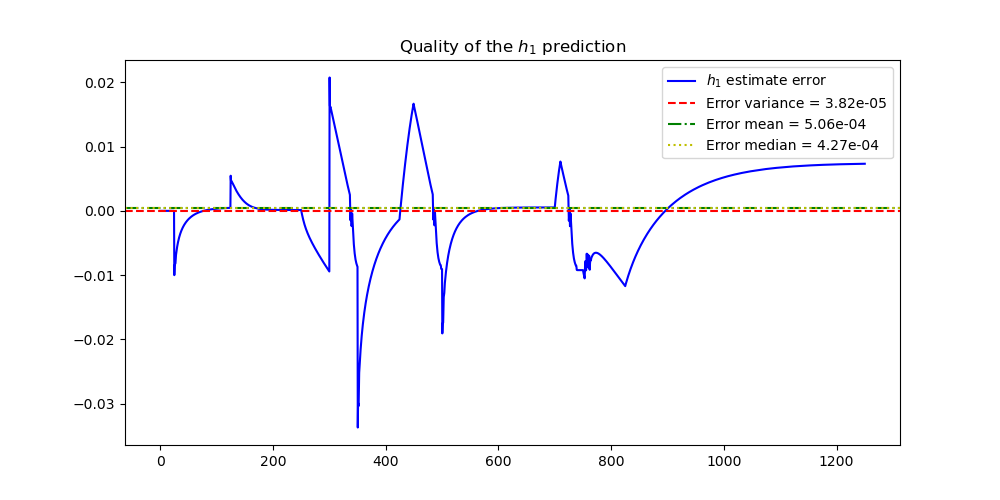

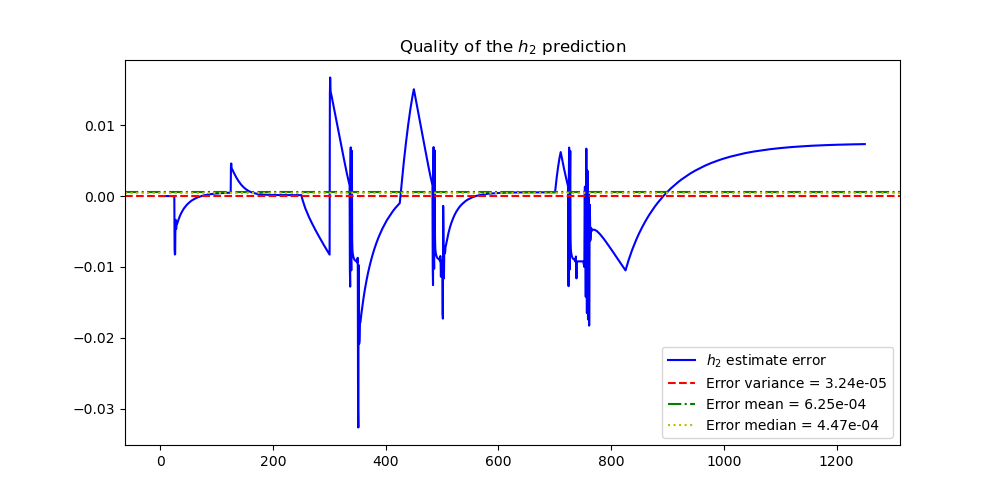

Temporary gain instability seems strongly correlated with rapid changes in q1

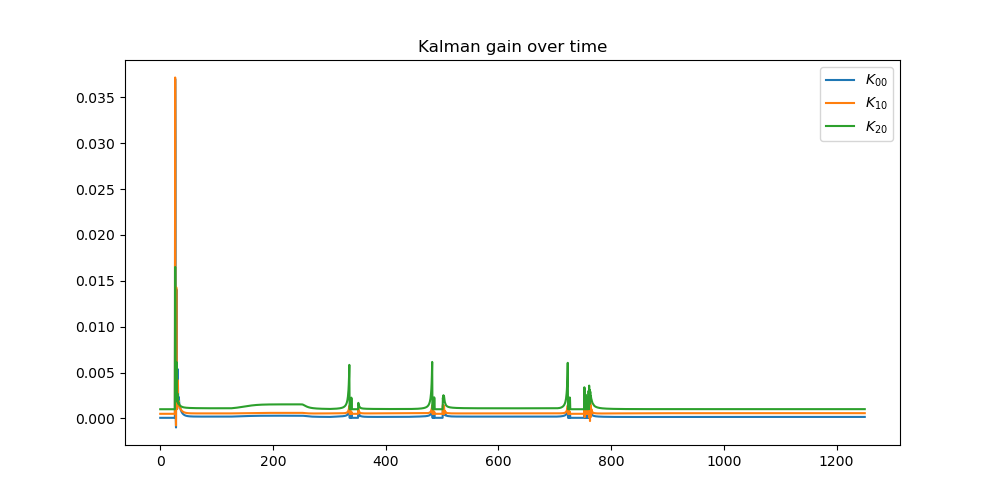

In [3]:
class KalmanOutput:
    h1 = []
    h2 = []
    q1 = []
    q2 = []
    Ks = []
    Ps = []
    Ss = []
    ys = []
    predictions = []

def KalmanStepEx1(q1, q2, V, P, R, H, Q, a, k, S1, S2):

    F = np.array([[(1 - a/S1), a/S1 , 0],
              [a/S2, (1 - a/S2), -(1 / S2)],
              [0, k*((1/sqrt(V[1, 0])) if V[1, 0] > 0.01 else 0), 0]])

    Bu = np.array([[q1/S1], [0], [0]])
    P = F @ P @ F.T + Q
    pred = F @ V + Bu
    S = H @ P @ H.T + R
    z = np.array([[q2]])
    y = z - H @ pred
    K = P @ H.T @ pinv(S)
    x = pred + (K @ y)
    P = P - K @ H @ P
    return x, P, pred, K, S, y
def KalmanEx1(inputs, readings, V, P, R, H, Qfv:npt.ArrayLike|types.FunctionType, k, a, S1, S2)->KalmanOutput:
    output = KalmanOutput()
    i = 0
    while readings[i] == 0:

        # prepend the outputs to ensure correct array length
        output.q1.append(0)
        output.q2.append(0)
        output.h1.append(0)
        output.h2.append(0)
        i += 1
    first_index = i
    while i < len(readings):
        q1 = inputs[i]
        q2 = readings[i]
        Q = Qfv(V, P) if type(Qfv) == types.FunctionType else Qfv
        V, P, pred, K, S, y = KalmanStepEx1(q1, q2, V, P, R, H, Q, a, k, S1, S2)

        output.q1.append(q1)
        output.h1.append(V[0, 0])
        output.h2.append(V[1, 0])
        output.q2.append(V[2, 0])

        output.Ks.append(K)
        output.Ss.append(S)
        output.ys.append(y)
        output.Ps.append(P)
        output.predictions.append(pred)

        i += 1

    # prepend the outputs to ensure correct array length
    output.predictions = [output.predictions[0] for _ in range (first_index)] + output.predictions
    output.Ks = [output.Ks[0] for _ in range(first_index)] + output.Ks
    output.Ss = [output.Ss[0] for _ in range(first_index)] + output.Ss
    output.ys = [output.ys[0] for _ in range(first_index)] + output.ys
    output.Ps = [output.Ps[0] for _ in range(first_index)] + output.Ps
    return output

step = data.t[1]-data.t[0]
V = np.array([[0],
             [0],
             [0]])
P = np.diag([1, 1, 1])
R = np.array([[10]])
H = np.array([[0, 0, 1]])
Qvar = 0.01
Q = np.array([[0.015625, 0.0625, 0.0625], # Assuming gausian noise
              [0.0625, 0.25, 0.5],
              [0.125, 0.5, 1.0]]) * Qvar

results = KalmanEx1(data.q1, data.q2_measured, V, P, R, H, Q, data.k, data.a, data.S1, data.S2)

display(Markdown("## Initial values"))
display(Markdown(f"$V = {MatrixToLatex(V.T)}^T$"))
display(Markdown("$q_2$ has relatively high noise level, but can be predicted with high degree of certainty from $h_2$, thus a high process noise value is appropriate here."))
display(Markdown(f"$R = {MatrixToLatex(R)}$"))
display(Markdown("Initial variance seems to have little effect"))
display(Markdown(f"$P = {MatrixToLatex(P)}$"))
display(Markdown(f"$H = {MatrixToLatex(H)}$"))
display(Markdown(f"Assuming gaussian white noise of variance {Qvar}"))
display(Markdown(f"$Q = {MatrixToLatex(Q)}$"))

display(Markdown("## Results"))

fig = plt.figure()
plt.title("predicted values for $h_1$ and $h_2$ compared to the real values")

plt.plot(data.t, results.h1, label="$h_1$ estimated")
plt.plot(data.t, data.h1, label="$h_1$ real")
plt.plot(data.t, results.h2, label="$h_2$ estimated")
plt.plot(data.t, data.h2, label="$h_2$ real")

plt.legend()
plt.show()

display(Markdown("Note: the curves might be too close to distinguish them without using the zoom tool"))

fig = plt.figure()
plt.title("$q_2$ estimate compared to the real value")

plt.plot(data.t, results.q2, label="$q_2$ estimated")
plt.plot(data.t, data.q2, label="$q_2$ real")

plt.legend()
plt.show()

fig = plt.figure()
plt.title("$q_2$ estimate compared to the raw sensor output")

plt.plot(data.t, results.q2, label="$q_2$ estimated")
plt.plot(data.t, data.q2_measured, label="$q_2$ measured", alpha=0.6)

plt.legend()
plt.show()

def compareh(data, hbase, hpred, name):
    fig = plt.figure()
    plt.title(f"Quality of the {name} prediction")

    dif = hbase-hpred
    var = np.var(dif)
    mean = np.mean(dif)
    median = np.median(dif)
    plt.plot(data.t, dif, label=f"{name} estimate error", color = "b", linestyle = "-")
    plt.axhline(var, label=f"Error variance = {var:.2e}", color = "r", linestyle = "--")
    plt.axhline(mean, label=f"Error mean = {mean:.2e}", color = "g", linestyle = "-.")
    plt.axhline(median, label=f"Error median = {median:.2e}", color = "y", linestyle = ":")

    plt.legend()
    plt.show()
compareh(data, data.h1, results.h1, "$h_1$")
compareh(data, data.h2, results.h2, "$h_2$")

fig = plt.figure()
plt.title("Kalman gain over time")

plt.plot(data.t, [k[0, 0] for k in results.Ks], label="$K_{00}$")
plt.plot(data.t, [k[1, 0] for k in results.Ks], label="$K_{10}$")
plt.plot(data.t, [k[2, 0] for k in results.Ks], label="$K_{20}$")

display(Markdown("Temporary gain instability seems strongly correlated with rapid changes in q1"))

plt.legend()
plt.show()


## Discussion

The filter can predict $h_2$ and $h_1$ with high accuracy, but does not handle sudden change in signal characteristics which occurs whenever the water level in both tanks drops to 0 as well as when the level begins to rise from 0. It might be beneficial to handle the case of an empty tank by stopping the filter or injecting dummy values.

Note that the filter is only ran after the water level begins to rise, the $q_2$ samples acquired before that point could be used to assertain noise characteristics of the sensor.